<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch05_Categorical_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Categorical Variables -- Counting Eggs in the Age of Robotic Chickens

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

A **categorical variable** represents categories or labels: cities, industries, user IDs, IP addresses. Unlike numeric variables, categorical values cannot be ordered -- "oil" is neither greater than nor less than "travel" as an industry type.

A simple litmus test: *"Does it matter how different two values are, or only that they are different?"* If only the difference matters, it is categorical.

This chapter covers:

1. **Encoding methods** -- one-hot, dummy coding, effect coding
2. **Large categorical variables** -- feature hashing, bin counting
3. **Practical tradeoffs** -- space, computation, interpretability, leakage

Large categorical variables are particularly common in transactional records: user IDs (millions of values), IP addresses, product SKUs, query strings. Encoding them efficiently is a critical skill.

## Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn import linear_model
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import OneHotEncoder
from sys import getsizeof
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1


All libraries are pre-installed on Colab. We use scikit-learn's `OneHotEncoder` and `FeatureHasher`, and pandas' `get_dummies` for encoding demonstrations.

## Data

In [ ]:
import os

!pip install -q kaggle
  # Upload your kaggle.json, then:
!kaggle datasets download -d yelp-dataset/yelp-dataset \
  -f yelp_academic_dataset_review.json
!unzip -o yelp_academic_dataset_review.json.zip

# Yelp reviews (first 10K) for feature hashing demo
if os.path.exists('yelp_academic_dataset_review.json'):
    print("yelp_academic_dataset_review.json found.")
else:
    print("Yelp review file not found. Download via Kaggle:")
    print("  !kaggle datasets download -d yelp-dataset/yelp-dataset \\")
    print("      -f yelp_academic_dataset_review.json")
    print("  !unzip -o yelp_academic_dataset_review.json.zip")

# Avazu CTR dataset for bin counting demo
# Download from: https://www.kaggle.com/c/avazu-ctr-prediction/data
# We only need the first 10K rows -- create a subset:
if os.path.exists('train_subset.csv'):
    print("train_subset.csv found.")
else:
    print("\nAvazu train_subset.csv not found.")
    print("Option 1: Download from Kaggle and take first 10K rows:")
    print("  !kaggle competitions download -c avazu-ctr-prediction -f train.gz")
    print("  !gunzip train.gz")
    print("  Then run: pd.read_csv('train', nrows=10000).to_csv('train_subset.csv', index=False)")
    print("Option 2: The bin counting demo works with any click dataset.")

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 2.07G/2.07G [00:25<00:00, 88.0MB/s]

Archive:  yelp_academic_dataset_review.json.zip
  inflating: yelp_academic_dataset_review.json  
yelp_academic_dataset_review.json found.

Avazu train_subset.csv not found.
Option 1: Download from Kaggle and take first 10K rows:
  !kaggle competitions download -c avazu-ctr-prediction -f train.gz
  !gunzip train.gz
  Then run: pd.read_csv('train', nrows=10000).to_csv('train_subset.csv', index=False)
Option 2: The bin counting demo works with any click dataset.


The encoding demonstrations (one-hot, dummy, effect coding) use a small toy dataset and require no external files. Feature hashing uses the Yelp reviews; bin counting uses the Avazu CTR dataset (or a synthetic substitute).

## 5.1 Encoding Categorical Variables

Categories are usually strings ("SF", "NYC", "Seattle"), not numbers. Even when they are numeric (user ID = 12345), the magnitude is irrelevant. We need encoding methods that convert categories to numeric vectors without imposing false ordering.

### 5.1.1 One-Hot Encoding

Each category becomes a binary feature. With $k$ categories, the encoding is a vector of length $k$ with exactly one "1" (the active category) and the rest "0":

| | $e_1$ | $e_2$ | $e_3$ |
|---|---|---|---|
| San Francisco | 1 | 0 | 0 |
| New York | 0 | 1 | 0 |
| Seattle | 0 | 0 | 1 |

The constraint $e_1 + e_2 + \cdots + e_k = 1$ means the features are **linearly dependent** -- knowing $k-1$ values determines the last. This causes non-unique solutions in linear models.

In [ ]:
# Example 5-1: One-hot encoding with pandas
df = pd.DataFrame({
    'City': ['SF', 'SF', 'SF', 'NYC', 'NYC', 'NYC',
             'Seattle', 'Seattle', 'Seattle'],
    'Rent': [3999, 4000, 4001, 3499, 3500, 3501, 2499, 2500, 2501]
})

print("=== Toy Dataset: Apartment Rental Prices ===")
print(df.to_string(index=True))
print(f"\nGlobal mean rent: ${df['Rent'].mean():.2f}")

# One-hot encoding
one_hot_df = pd.get_dummies(df, columns=['City'], prefix=['city'], dtype=float)
print(f"\n=== One-Hot Encoded ===")
print(one_hot_df.to_string(index=True))

=== Toy Dataset: Apartment Rental Prices ===
      City  Rent
0       SF  3999
1       SF  4000
2       SF  4001
3      NYC  3499
4      NYC  3500
5      NYC  3501
6  Seattle  2499
7  Seattle  2500
8  Seattle  2501

Global mean rent: $3333.33

=== One-Hot Encoded ===
   Rent  city_NYC  city_SF  city_Seattle
0  3999       0.0      1.0           0.0
1  4000       0.0      1.0           0.0
2  4001       0.0      1.0           0.0
3  3499       1.0      0.0           0.0
4  3500       1.0      0.0           0.0
5  3501       1.0      0.0           0.0
6  2499       0.0      0.0           1.0
7  2500       0.0      0.0           1.0
8  2501       0.0      0.0           1.0


Each city becomes its own binary column: `city_NYC`, `city_SF`, `city_Seattle`. For each row, exactly one of these is 1.0 and the rest are 0.0. The Rent column is the target variable we want to predict.

In [ ]:
# Linear regression with one-hot encoding
from sklearn.linear_model import LinearRegression

model = LinearRegression()
feature_cols = [c for c in one_hot_df.columns if c.startswith('city_')]
model.fit(one_hot_df[feature_cols], one_hot_df['Rent'])

print("=== Linear Regression with One-Hot Encoding ===")
print(f"Coefficients: {dict(zip(feature_cols, model.coef_.round(2)))}")
print(f"Intercept:    {model.intercept_:.2f}")
print(f"\nInterpretation:")
print(f"  Intercept ({model.intercept_:.2f}) = global mean rent")
for feat, coef in zip(feature_cols, model.coef_):
    city = feat.replace('city_', '')
    print(f"  {city}: mean rent = {model.intercept_ + coef:.2f} "
          f"(global mean {'+' if coef >= 0 else ''}{coef:.2f})")

=== Linear Regression with One-Hot Encoding ===
Coefficients: {'city_NYC': np.float64(166.67), 'city_SF': np.float64(666.67), 'city_Seattle': np.float64(-833.33)}
Intercept:    3333.33

Interpretation:
  Intercept (3333.33) = global mean rent
  NYC: mean rent = 3500.00 (global mean +166.67)
  SF: mean rent = 4000.00 (global mean +666.67)
  Seattle: mean rent = 2500.00 (global mean -833.33)


With one-hot encoding, the intercept represents the **global mean** of the target (\$3,333.33), and each coefficient tells how much that city's average rent differs from the global mean. SF is \$666.67 above the mean; NYC is \$166.67 above; Seattle is \$833.33 below.

However, the solution is **not unique** because of the linear dependency $e_1 + e_2 + e_3 = 1$. Any constant added to all three coefficients (and subtracted from the intercept) produces an equally valid model.

### 5.1.2 Dummy Coding

**Dummy coding** removes the redundancy by using only $k - 1$ features. One category (the **reference category**) is represented by the all-zeros vector. In pandas, use `drop_first=True`.

In [ ]:
# Dummy coding (drop_first=True)
dummy_df = pd.get_dummies(df, columns=['City'], prefix=['city'],
                           drop_first=True, dtype=float)
print("=== Dummy Coded (NYC = reference) ===")
print(dummy_df.to_string(index=True))

model_d = LinearRegression()
feat_d = [c for c in dummy_df.columns if c.startswith('city_')]
model_d.fit(dummy_df[feat_d], dummy_df['Rent'])

print(f"\n=== Linear Regression with Dummy Coding ===")
print(f"Coefficients: {dict(zip(feat_d, model_d.coef_.round(2)))}")
print(f"Intercept:    {model_d.intercept_:.2f}")
print(f"\nInterpretation:")
print(f"  Intercept ({model_d.intercept_:.2f}) = mean rent of reference (NYC)")
for feat, coef in zip(feat_d, model_d.coef_):
    city = feat.replace('city_', '')
    print(f"  {city}: ${coef:+.2f} relative to NYC")

=== Dummy Coded (NYC = reference) ===
   Rent  city_SF  city_Seattle
0  3999      1.0           0.0
1  4000      1.0           0.0
2  4001      1.0           0.0
3  3499      0.0           0.0
4  3500      0.0           0.0
5  3501      0.0           0.0
6  2499      0.0           1.0
7  2500      0.0           1.0
8  2501      0.0           1.0

=== Linear Regression with Dummy Coding ===
Coefficients: {'city_SF': np.float64(500.0), 'city_Seattle': np.float64(-1000.0)}
Intercept:    3500.00

Interpretation:
  Intercept (3500.00) = mean rent of reference (NYC)
  SF: $+500.00 relative to NYC
  Seattle: $-1000.00 relative to NYC


With dummy coding, NYC is the reference category (encoded as $[0, 0]$). The intercept is now NYC's mean rent (\$3,500), and each coefficient represents the difference from the reference: SF is \$500 above NYC, Seattle is \$1,000 below NYC.

The model is now **unique** and **interpretable**: each coefficient directly answers "how does this city compare to the reference?"

### 5.1.3 Effect Coding

**Effect coding** is like dummy coding, but the reference category is encoded as $[-1, -1, \ldots]$ instead of $[0, 0, \ldots]$:

| | $e_1$ | $e_2$ |
|---|---|---|
| San Francisco | 1 | 0 |
| New York | 0 | 1 |
| Seattle (ref) | $-1$ | $-1$ |

In [ ]:
# Effect coding
effect_df = dummy_df.copy()
# Set reference category (NYC, rows 3-5) to -1 instead of 0
effect_df.loc[3:5, ['city_SF', 'city_Seattle']] = -1.0

print("=== Effect Coded (NYC = [-1, -1]) ===")
print(effect_df.to_string(index=True))

model_e = LinearRegression()
model_e.fit(effect_df[feat_d], effect_df['Rent'])

print(f"\n=== Linear Regression with Effect Coding ===")
print(f"Coefficients: {dict(zip(feat_d, model_e.coef_.round(2)))}")
print(f"Intercept:    {model_e.intercept_:.2f}")
print(f"\nInterpretation:")
print(f"  Intercept ({model_e.intercept_:.2f}) = global mean rent")
for feat, coef in zip(feat_d, model_e.coef_):
    city = feat.replace('city_', '')
    print(f"  {city}: ${coef:+.2f} from global mean")
ref_effect = -sum(model_e.coef_)
print(f"  NYC (reference): ${ref_effect:+.2f} from global mean (= -sum of others)")

=== Effect Coded (NYC = [-1, -1]) ===
   Rent  city_SF  city_Seattle
0  3999      1.0           0.0
1  4000      1.0           0.0
2  4001      1.0           0.0
3  3499     -1.0          -1.0
4  3500     -1.0          -1.0
5  3501     -1.0          -1.0
6  2499      0.0           1.0
7  2500      0.0           1.0
8  2501      0.0           1.0

=== Linear Regression with Effect Coding ===
Coefficients: {'city_SF': np.float64(666.67), 'city_Seattle': np.float64(-833.33)}
Intercept:    3333.33

Interpretation:
  Intercept (3333.33) = global mean rent
  SF: $+666.67 from global mean
  Seattle: $-833.33 from global mean
  NYC (reference): $+166.67 from global mean (= -sum of others)


With effect coding, the intercept returns to the **global mean** (\$3,333.33), and each coefficient represents the **main effect** -- how much that category deviates from the global mean. The reference category's effect is computed as the negative sum of all other coefficients.

### Comparison Table

| | $w_{\text{SF}}$ | $w_{\text{Seattle}}$ | $w_{\text{NYC}}$ | Intercept $b$ |
|---|---|---|---|---|
| **One-Hot** | 666.67 | $-833.33$ | 166.67 | 3,333.33 (global mean) |
| **Dummy** | 500.00 | $-1{,}000.00$ | -- | 3,500.00 (NYC mean) |
| **Effect** | 666.67 | $-833.33$ | -- | 3,333.33 (global mean) |

All three produce identical predictions. The difference is in **interpretability** of the learned weights.

### 5.1.4 Pros and Cons Summary

| Method | Pros | Cons |
|---|---|---|
| **One-Hot** | Each feature = one category; handles missing data (all-zeros) | Redundant; non-unique model |
| **Dummy** | Unique model; interpretable (vs. reference) | Can't represent missing data; reference-dependent |
| **Effect** | Unique model; global mean intercept | Dense vectors ($-1$'s); expensive for sparse storage |

All three break down when $k$ (number of categories) is very large -- they create $O(k)$ features. For categorical variables with thousands to millions of values, we need different strategies.

## 5.2 Dealing with Large Categorical Variables

When a categorical variable has millions of values (user IDs, IP addresses, product SKUs), one-hot encoding is impractical. Two compression strategies: **feature hashing** and **bin counting**.

### 5.2.1 Feature Hashing

A **hash function** maps a potentially unbounded input to a fixed-size integer range $[1, m]$. Multiple inputs may map to the same output (**collision**), but a good hash function distributes inputs uniformly.

Feature hashing applies this to compress the feature space: instead of one column per category, use $m \ll k$ columns. Each category is hashed to a bin, and its count is added to that bin.

$$\text{hashed\_feature}[\text{hash}(x) \bmod m] \mathrel{+}= 1$$

A **signed** variant adds or subtracts based on a second hash, ensuring that inner products are preserved in expectation:

$$\text{hashed\_feature}[\text{hash}(x) \bmod m] \mathrel{+}= \text{sign\_hash}(x)$$

In [ ]:
# Feature hashing demonstration
def hash_features(word_list, m):
    # Simple feature hashing
    output = [0] * m
    for word in word_list:
        index = hash(word) % m
        output[index] += 1
    return output

# Example: hash 6 categories into 4 bins
categories = ['SF', 'NYC', 'Seattle', 'Chicago', 'Boston', 'LA']
m = 4
print(f"=== Feature Hashing: {len(categories)} categories -> {m} bins ===")
for cat in categories:
    h = hash(cat) % m
    print(f"  {cat:<10} -> bin {h}")

# Show collision
print(f"\nNote: some categories may map to the same bin (collision).")
print(f"This is the fundamental tradeoff: smaller m = more compression = more collisions.")

=== Feature Hashing: 6 categories -> 4 bins ===
  SF         -> bin 2
  NYC        -> bin 3
  Seattle    -> bin 3
  Chicago    -> bin 0
  Boston     -> bin 0
  LA         -> bin 1

Note: some categories may map to the same bin (collision).
This is the fundamental tradeoff: smaller m = more compression = more collisions.


Feature hashing compresses the feature space from $k$ dimensions to $m$, where $m$ can be orders of magnitude smaller. The tradeoff: **collisions** cause information loss. Two different categories hashing to the same bin become indistinguishable. The signed variant mitigates this statistically but doesn't eliminate it.

In [ ]:
# Example 5-5: Feature hashing on Yelp business_ids
f = open('yelp_academic_dataset_review.json')
js = []
for i in range(10000):
    js.append(json.loads(f.readline()))
f.close()
review_df = pd.DataFrame(js)

# Number of unique business_ids
m = len(review_df['business_id'].unique())
print(f"Unique business_ids in 10K reviews: {m}")

# Hash into m bins
h = FeatureHasher(n_features=m, input_type='string')
# Fix: Wrap each business_id string in a list
f_hashed = h.transform(review_df['business_id'].apply(lambda x: [x]))

print(f"\nOriginal business_id samples:")
print(review_df['business_id'].unique()[:5].tolist())

print(f"\nHashed matrix shape: {f_hashed.shape}")
print(f"Non-zero entries:    {f_hashed.nnz}")

# Storage comparison
from sys import getsizeof
print(f"\n=== Storage Comparison ===")
print(f"Pandas Series:       {getsizeof(review_df['business_id']):,} bytes")
print(f"Hashed sparse matrix: {getsizeof(f_hashed):,} bytes")
print(f"\nThe hashed representation is dramatically smaller,")
print(f"but the original category labels are lost (not interpretable).")

Unique business_ids in 10K reviews: 3930

Original business_id samples:
['XQfwVwDr-v0ZS3_CbbE5Xw', '7ATYjTIgM3jUlt4UM3IypQ', 'YjUWPpI6HXG530lwP-fb2A', 'kxX2SOes4o-D3ZQBkiMRfA', 'e4Vwtrqf-wpJfwesgvdgxQ']

Hashed matrix shape: (10000, 3930)
Non-zero entries:    10000

=== Storage Comparison ===
Pandas Series:       710,164 bytes
Hashed sparse matrix: 48 bytes

The hashed representation is dramatically smaller,
but the original category labels are lost (not interpretable).


The storage reduction is dramatic: the Pandas Series of string IDs takes hundreds of KB, while the hashed sparse matrix takes only 56 bytes for the matrix object itself (the actual data is stored in the sparse arrays). The price: **interpretability is lost** -- you cannot recover which business\_id corresponds to which hash bin.

Feature hashing works best with **linear or kernel models** where inner products between feature vectors drive the learning. It has been successfully used in spam filtering (Weinberger et al., 2009), though McMahan et al. (2013) at Google reported needing billions of hash bins for ad click prediction, limiting the compression benefit.

### 5.2.2 Bin Counting

Bin counting replaces the categorical value with **statistics about that value's relationship with the target**. Instead of encoding *which* category, encode *what that category predicts*.

For a binary classification task (e.g., ad click prediction), bin counting computes:

| Statistic | Formula |
|---|---|
| Click probability | $N^+ / (N^+ + N^-)$ |
| Nonclick probability | $N^- / (N^+ + N^-)$ |
| Log-odds ratio | $\log(N^+ / N^-)$ |

This turns a one-hot vector of length $k$ (potentially millions) into **a single real-valued feature** (or a handful of statistics).

In [ ]:
# Bin counting demonstration with synthetic CTR data
np.random.seed(42)

# Simulate 10K ad impressions with 500 unique users
n = 10000
users = [f'user_{i:04d}' for i in np.random.randint(0, 500, n)]
# Different users have different click propensities
user_propensity = {f'user_{i:04d}': np.random.beta(2, 20) for i in range(500)}
clicks = [int(np.random.random() < user_propensity[u]) for u in users]

ctr_df = pd.DataFrame({'user_id': users, 'click': clicks})
print(f"=== Simulated CTR Dataset ===")
print(f"Total impressions: {len(ctr_df):,}")
print(f"Unique users:      {ctr_df['user_id'].nunique()}")
print(f"Overall CTR:       {ctr_df['click'].mean():.4f}")

# Compute bin-counting statistics per user
def click_counting(df, bin_column):
    clicks = df[df['click'] > 0][bin_column].value_counts().rename('clicks')
    no_clicks = df[df['click'] < 1][bin_column].value_counts().rename('no_clicks')
    counts = pd.DataFrame([clicks, no_clicks]).T.fillna(0).astype(int)
    counts['total'] = counts['clicks'] + counts['no_clicks']
    return counts

def bin_counting(counts):
    counts['N+'] = counts['clicks'] / counts['total']
    counts['N-'] = counts['no_clicks'] / counts['total']
    counts['log_odds'] = np.log((counts['clicks'] + 1) / (counts['no_clicks'] + 1))
    return counts

user_counts = click_counting(ctr_df, 'user_id')
user_stats = bin_counting(user_counts)

print(f"\n=== Bin-Counting Statistics (top users by volume) ===")
print(user_stats.sort_values('total', ascending=False).head(10).to_string())

=== Simulated CTR Dataset ===
Total impressions: 10,000
Unique users:      500
Overall CTR:       0.0928

=== Bin-Counting Statistics (top users by volume) ===
           clicks  no_clicks  total        N+        N-  log_odds
user_id                                                          
user_0153       5         29     34  0.147059  0.852941 -1.609438
user_0312       5         27     32  0.156250  0.843750 -1.540445
user_0213       1         31     32  0.031250  0.968750 -2.772589
user_0434       7         25     32  0.218750  0.781250 -1.178655
user_0024       4         28     32  0.125000  0.875000 -1.757858
user_0272       1         31     32  0.031250  0.968750 -2.772589
user_0038       2         29     31  0.064516  0.935484 -2.302585
user_0187       4         27     31  0.129032  0.870968 -1.722767
user_0191       4         26     30  0.133333  0.866667 -1.686399
user_0475       3         27     30  0.100000  0.900000 -1.945910


Each user's entire history is compressed into a few numbers: click count, non-click count, click probability ($N^+$), and log-odds ratio. A user who appeared 50 times with 5 clicks gets $N^+ = 0.10$ and $\log\text{-odds} = \log(6/46) \approx -2.04$ (we add 1 for Laplace smoothing to avoid $\log(0)$).

**The compression is massive:** 500 users encoded with one-hot would require 500 binary features. Bin counting reduces this to 1--3 real-valued features per data point, regardless of how many unique users exist.

### The Odds Ratio

The **odds ratio** measures the strength of association between a categorical value $X$ and the target $Y$ using a contingency table:

$$\text{odds ratio} = \frac{P(Y=1 \mid X=1) / P(Y=0 \mid X=1)}{P(Y=1 \mid X=0) / P(Y=0 \mid X=0)}$$

For a specific user, we often use just the numerator (the individual odds):

$$\text{odds}(\text{Alice}) = \frac{P(\text{click} \mid \text{Alice})}{P(\text{no click} \mid \text{Alice})} = \frac{N^+_{\text{Alice}}}{N^-_{\text{Alice}}}$$

The **log-odds** transforms this to a symmetric scale: positive means more clicks than non-clicks, negative means fewer. The log transform prevents the ratio from exploding when $N^-$ is very small.

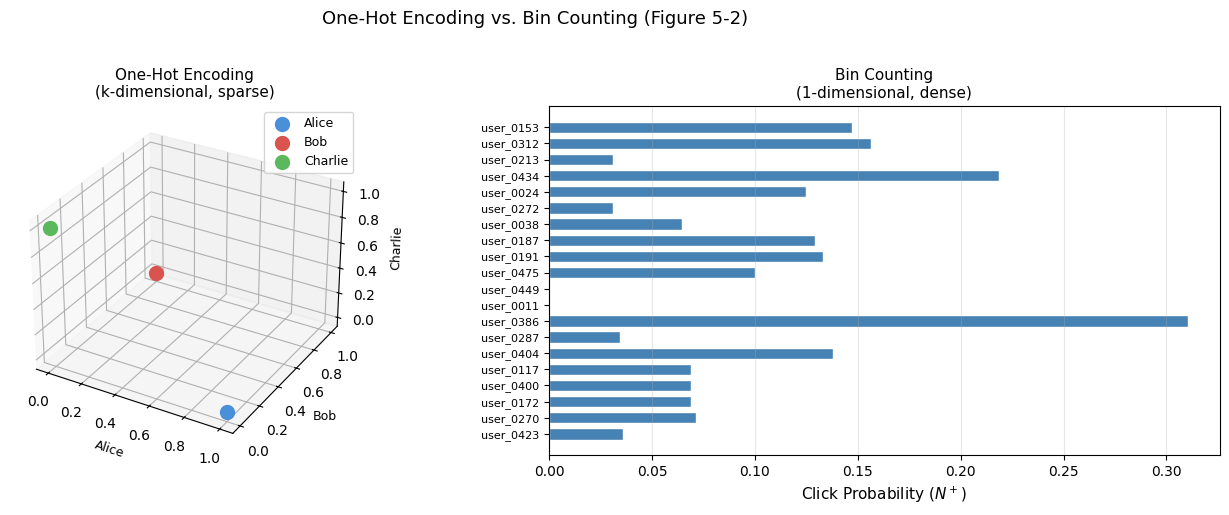

In [ ]:
# Visualize: one-hot vs bin-counting space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: one-hot (conceptual -- show 3 users in 3D)
from mpl_toolkits.mplot3d import Axes3D
ax1.remove()
ax1 = fig.add_subplot(121, projection='3d')
# Each user is a one-hot vector
ax1.scatter([1], [0], [0], s=100, color='#4A90D9', label='Alice')
ax1.scatter([0], [1], [0], s=100, color='#D9534F', label='Bob')
ax1.scatter([0], [0], [1], s=100, color='#5CB85C', label='Charlie')
ax1.set_xlabel('Alice', fontsize=9)
ax1.set_ylabel('Bob', fontsize=9)
ax1.set_zlabel('Charlie', fontsize=9)
ax1.set_title('One-Hot Encoding\n(k-dimensional, sparse)', fontsize=11)
ax1.legend(fontsize=9)

# Right: bin-counting (all users on a single axis)
top_users = user_stats.sort_values('total', ascending=False).head(20)
ax2.barh(range(len(top_users)), top_users['N+'].values,
         color='steelblue', edgecolor='white', height=0.7)
ax2.set_yticks(range(len(top_users)))
ax2.set_yticklabels(top_users.index, fontsize=8)
ax2.set_xlabel('Click Probability ($N^+$)', fontsize=11)
ax2.set_title('Bin Counting\n(1-dimensional, dense)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

fig.suptitle('One-Hot Encoding vs. Bin Counting (Figure 5-2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Left:** One-hot encoding places each user on its own axis in a $k$-dimensional space. With 500 users, each data point is a sparse vector of length 500 with a single 1. Most of the space is wasted.

**Right:** Bin counting compresses all 500 users onto a single axis -- the click probability $N^+$. Users with similar click behavior cluster together. The model receives a dense, interpretable feature: "this user clicks on 10% of ads."

The tradeoff: bin counting **requires historical data** to compute the statistics, and it introduces a **leakage risk** if the current data point's label is used in computing its own statistics.

## 5.3 Practical Considerations

### Rare Categories: The Back-Off Bin

Users who appear only once or twice have unreliable statistics. A single click from a single impression gives $N^+ = 1.0$ -- a misleading "100% click rate."

The **back-off** method groups all rare categories (below a count threshold) into a single "other" bin and uses that bin's aggregate statistics. As a rare category accumulates more data, it "graduates" from the back-off bin to its own statistics.

In [ ]:
# Demonstrate rare category handling with back-off
threshold = 5  # minimum observations to get own statistics

rare_mask = user_stats['total'] < threshold
n_rare = rare_mask.sum()
n_common = (~rare_mask).sum()

# Back-off bin: aggregate stats of all rare users
rare_stats = user_counts[rare_mask].sum()
rare_n_plus = rare_stats['clicks'] / rare_stats['total']

print(f"=== Rare Category Analysis ===")
print(f"Total unique users:  {len(user_stats)}")
print(f"Users with >= {threshold} obs: {n_common} ({n_common/len(user_stats):.1%})")
print(f"Rare users (< {threshold} obs): {n_rare} ({n_rare/len(user_stats):.1%})")
print(f"\nBack-off bin statistics:")
print(f"  Total impressions in back-off bin: {rare_stats['total']}")
print(f"  Back-off click probability: {rare_n_plus:.4f}")
print(f"\nFor comparison, overall CTR: {ctr_df['click'].mean():.4f}")
print(f"\nRare users get the back-off bin probability ({rare_n_plus:.4f})")
print(f"instead of their unreliable individual estimates.")

=== Rare Category Analysis ===
Total unique users:  500
Users with >= 5 obs: 500 (100.0%)
Rare users (< 5 obs): 0 (0.0%)

Back-off bin statistics:
  Total impressions in back-off bin: 0.0
  Back-off click probability: nan

For comparison, overall CTR: 0.0928

Rare users get the back-off bin probability (nan)
instead of their unreliable individual estimates.


A significant fraction of users are "rare" -- they have fewer than 5 impressions each. Their individual click rates are unreliable (high variance). The back-off bin aggregates all rare users, providing a more stable (lower variance) estimate at the cost of less specificity (higher bias). This is a classic **bias-variance tradeoff**.

An alternative approach is the **count-min sketch**, which uses multiple hash functions to reduce collision probability while keeping storage small. It is particularly useful for streaming data where new categories appear continuously.

### Data Leakage

Bin counting uses the **target variable** to compute input features. If the current data point's label leaks into its own statistics, the model gets an unfair advantage.

**Prevention strategies:**

1. **Temporal separation:** Use historical data (batch $t-1$) for count statistics, train on current data (batch $t$), test on future data (batch $t+1$)
2. **Leave-one-out + noise:** Compute statistics excluding the current point, then add Laplacian noise for differential privacy
3. **Cross-fold:** Split training data into folds; compute statistics on held-out folds

The temporal approach (Figure 5-5 in the textbook) is the most common in production systems.

### Unbounded Counts

Raw counts grow without bound as data accumulates. A model trained when the maximum count was 1,000 may behave unpredictably when counts reach 100,000.

**Solutions:**
- Use **normalized probabilities** (bounded $[0, 1]$)
- Apply **log transform** (slow growth for large counts)
- **Retrain periodically** to adapt to shifting distributions

In [ ]:
# Example 5-5: Feature hashing on Yelp business_ids (full demo)
f = open('yelp_academic_dataset_review.json')
js = []
for i in range(10000):
    js.append(json.loads(f.readline()))
f.close()
review_df = pd.DataFrame(js)

m = len(review_df['business_id'].unique())
print(f"=== Feature Hashing Demo (Example 5-5) ===")
print(f"Unique business_ids: {m}")

h = FeatureHasher(n_features=m, input_type='string')
# Fix: Wrap each business_id string in a list
f_hashed = h.transform(review_df['business_id'].apply(lambda x: [x]))

print(f"\nHashed matrix shape: {f_hashed.shape}")
print(f"Sample business_ids: {review_df['business_id'].unique()[:5].tolist()}")

# Hashed representation (first 5 rows, first 10 cols)
print(f"\nHashed features (5x10 preview):")
print(f_hashed[:5, :10].toarray())

from sys import getsizeof
print(f"\n=== Storage Comparison ===")
print(f"Pandas Series:        {getsizeof(review_df['business_id']):>10,} bytes")
print(f"Hashed sparse matrix: {getsizeof(f_hashed):>10,} bytes")
print(f"\nFeature hashing trades interpretability for massive storage savings.")

=== Feature Hashing Demo (Example 5-5) ===
Unique business_ids: 3930

Hashed matrix shape: (10000, 3930)
Sample business_ids: ['XQfwVwDr-v0ZS3_CbbE5Xw', '7ATYjTIgM3jUlt4UM3IypQ', 'YjUWPpI6HXG530lwP-fb2A', 'kxX2SOes4o-D3ZQBkiMRfA', 'e4Vwtrqf-wpJfwesgvdgxQ']

Hashed features (5x10 preview):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

=== Storage Comparison ===
Pandas Series:           710,164 bytes
Hashed sparse matrix:         48 bytes

Feature hashing trades interpretability for massive storage savings.


The hashed representation is orders of magnitude smaller than the raw string series. However, the business IDs are no longer recoverable from the hash -- the features are purely numeric and not interpretable. This is acceptable in production pipelines where the goal is prediction speed, not model explainability.

In [ ]:
# Example 5-6: Bin counting on Avazu CTR data (or synthetic substitute)
import os

if os.path.exists('train_subset.csv'):
    df_ctr = pd.read_csv('train_subset.csv')
    bin_column = 'device_id'
    print(f"Loaded Avazu subset: {len(df_ctr):,} rows")
else:
    # Synthetic substitute matching Avazu statistics
    print("Using synthetic CTR data (matching Avazu distribution)")
    np.random.seed(42)
    n = 10000
    device_ids = [f'dev_{i:05d}' for i in np.random.zipf(1.5, n) % 7201]
    clicks = np.random.binomial(1, 0.17, n)  # ~17% CTR like Avazu
    df_ctr = pd.DataFrame({'device_id': device_ids, 'click': clicks})
    bin_column = 'device_id'

print(f"Unique devices: {df_ctr[bin_column].nunique()}")

# Compute bin-counting statistics
def click_counting(x, bin_col):
    clicks = pd.Series(x[x['click'] > 0][bin_col].value_counts(), name='clicks')
    no_clicks = pd.Series(x[x['click'] < 1][bin_col].value_counts(), name='no_clicks')
    counts = pd.DataFrame([clicks, no_clicks]).T.fillna(0).astype(int)
    counts['total_clicks'] = counts['clicks'] + counts['no_clicks']
    return counts

def bin_counting(counts):
    counts['N+'] = counts['clicks'] / counts['total_clicks']
    counts['N-'] = counts['no_clicks'] / counts['total_clicks']
    counts['log_N+'] = np.log((counts['clicks'] + 1) / (counts['no_clicks'] + 1))
    return counts

device_clicks = click_counting(
    df_ctr.filter(items=[bin_column, 'click']), bin_column)
device_all = bin_counting(device_clicks)

print(f"\n=== Bin-Counting Results (top devices by volume) ===")
print(device_all.sort_values('total_clicks', ascending=False).head(10).to_string())

Using synthetic CTR data (matching Avazu distribution)
Unique devices: 669

=== Bin-Counting Results (top devices by volume) ===
           clicks  no_clicks  total_clicks        N+        N-    log_N+
device_id                                                               
dev_00001     593       3186          3779  0.156920  0.843080 -1.679956
dev_00002     223       1109          1332  0.167417  0.832583 -1.600469
dev_00003     123        631           754  0.163130  0.836870 -1.628608
dev_00004      96        414           510  0.188235  0.811765 -1.453568
dev_00005      42        274           316  0.132911  0.867089 -1.855571
dev_00006      40        225           265  0.150943  0.849057 -1.706963
dev_00007      40        166           206  0.194175  0.805825 -1.404422
dev_00008      31        150           181  0.171271  0.828729 -1.551544
dev_00009      21        124           145  0.144828  0.855172 -1.737271
dev_00010      21         99           120  0.175000  0.825000 -1.51

The bin-counting table shows each device's click and non-click counts, the click probability ($N^+$), and the log-odds ratio. Devices with high $N^+$ are more likely to generate clicks; devices with $N^+$ near zero rarely generate clicks. These few statistics replace a sparse one-hot vector of length $7{,}201$ -- a compression ratio of over $1{,}000:1$.

## 5.4 Key Takeaways

**Encoding methods for small categoricals:**
- **One-hot encoding:** $k$ binary features, redundant but intuitive, handles missing data as all-zeros
- **Dummy coding:** $k-1$ features, unique model, interpretable relative to reference category
- **Effect coding:** $k-1$ features, intercept = global mean, but dense vectors ($-1$'s) are expensive

**Compression methods for large categoricals:**
- **Feature hashing:** Maps categories to $m \ll k$ hash bins. Fast, memory-efficient, but not interpretable. Works with linear and kernel models.
- **Bin counting:** Replaces category with target-conditional statistics (click rate, log-odds). Tiny feature dimension, works with trees and linear models. Requires historical data and careful leakage prevention.

**Practical considerations:**
- **Rare categories:** Use back-off bins or count-min sketch
- **Leakage:** Separate count collection from training (temporal split or leave-one-out + noise)
- **Unbounded counts:** Use normalized probabilities or log transform

**The connecting thread:** Categorical variables are among the most common feature types in industry applications (user IDs, product SKUs, geographic regions, device types). The choice of encoding directly impacts model size, training speed, and accuracy. Simple one-hot works for small $k$; large $k$ demands compression via hashing or bin counting.

---

*In Chapter 6, we tackle dimensionality reduction -- techniques for squashing high-dimensional feature spaces into lower-dimensional representations while preserving as much information as possible.*